# Sparse Pruning Classification Demo
Binary classification example with the sparse-pruning estimators.

In [1]:
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from imodels import SPTreeClassifier, SPTreeClassifierCV
from sklearn import tree
import matplotlib.pyplot as plt

In [2]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y
)

In [3]:
sp_tree = SPTreeClassifierCV(
    estimator_=DecisionTreeClassifier(max_leaf_nodes=20, random_state=42),
    sp_alpha_list=[0, 0.5, 1, 5, 10],
    reg_param_list=[0, 0.5, 1, 5],
    cv=3,
    random_state=42,
)
sp_tree.fit(X_train, y_train)

sp_tree_acc = accuracy_score(y_test, sp_tree.predict(X_test))
sp_tree_acc

0.9361702127659575

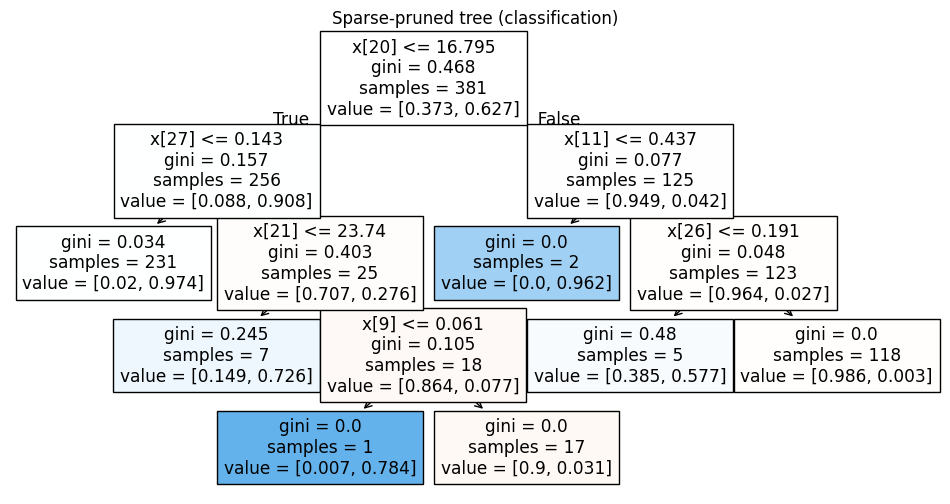

In [4]:
plt.figure(figsize=(12, 6))
tree.plot_tree(sp_tree.estimator_, max_depth=4, filled=True)
plt.title("Sparse-pruned tree (classification)")
plt.show()

In [5]:
dt = DecisionTreeClassifier(max_leaf_nodes=20, random_state=42)
dt.fit(X_train, y_train)

dt_acc = accuracy_score(y_test, dt.predict(X_test))
dt_acc

0.9148936170212766

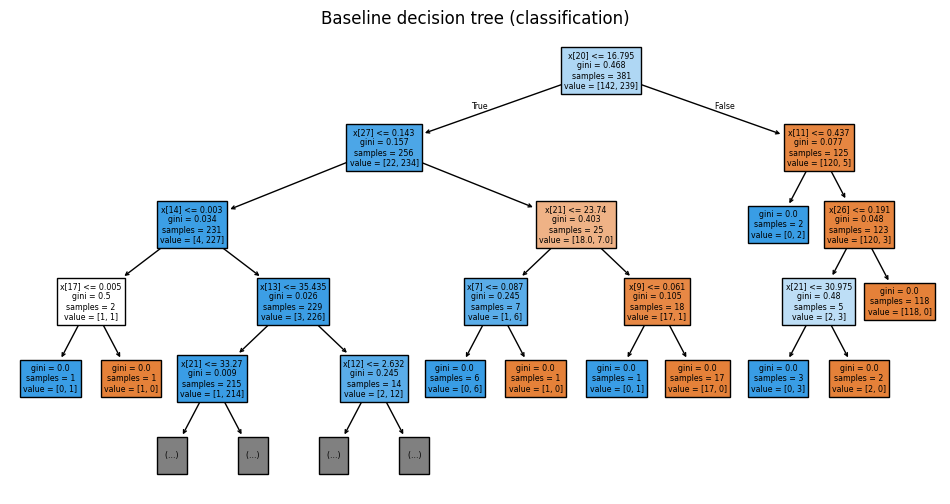

In [6]:
plt.figure(figsize=(12, 6))
tree.plot_tree(dt, max_depth=4, filled=True)
plt.title("Baseline decision tree (classification)")
plt.show()

In [7]:
sp_forest = SPTreeClassifier(
    estimator_=RandomForestClassifier(
        n_estimators=25, max_leaf_nodes=20, random_state=42
    ),
    sp_alpha=1,
    prune_set="oob",
)
sp_forest.fit(X_train, y_train)

sp_forest_acc = accuracy_score(y_test, sp_forest.predict(X_test))
sp_forest_acc

0.9361702127659575

In [8]:
rf = RandomForestClassifier(n_estimators=25, max_leaf_nodes=20, random_state=42)
rf.fit(X_train, y_train)

rf_acc = accuracy_score(y_test, rf.predict(X_test))
rf_acc

0.9361702127659575